# Quantum Chemistry: Toy H2 Hamiltonian Solver

This notebook uses a standard small qubit Hamiltonian model for molecular hydrogen after symmetry reduction. It computes the ground energy and demonstrates low-energy filtering on the chemistry Hamiltonian.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a standard two-qubit toy H2 Hamiltonian near equilibrium geometry.

**QSVT implementation.** It builds a ground-space projector polynomial after shifting and rescaling the molecular Hamiltonian. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact diagonalization gives the ground energy and filtered-state reference. The notebook does not outperform classical chemistry solvers; it demonstrates the low-energy projector primitive that QSVT would apply to larger block-encoded molecular Hamiltonians.


## Variable definitions

- `c0` through `c4`: coefficients of the two-qubit H2 Hamiltonian terms.
- `H`: molecular toy Hamiltonian matrix.
- `energies`, `vecs`: exact eigenvalues and eigenvectors.
- `ground_energy`: lowest exact energy.
- `bond_length_angstrom`: illustrated H-H bond length.
- `cutoff`: energy threshold between ground and excited states.
- `scale`: spectral scale around the cutoff.
- `A`: rescaled Hamiltonian for the projector polynomial.
- `coeffs`: projector polynomial coefficients.
- `P_ground`: polynomial ground-space projector.
- `trial`, `filtered`: trial state before and after projection.
- `ground_vec`: exact ground-state vector.
- `initial_overlap`, `filtered_overlap`: ground-state probabilities before and after filtering.
- `energy_estimate`: energy expectation of the filtered state.
- `proton_positions`, `electron_x`, `electron_cloud`, `xs`, `fig`, and `axes` are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.design import design_projector_polynomial
from qsvt.hamiltonians import pauli_string_matrix
from qsvt.polynomials import eval_polynomial
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

# Common two-qubit H2 example coefficients near the equilibrium geometry.
c0 = -1.052373245772859
c1 = 0.39793742484318045
c2 = -0.39793742484318045
c3 = -0.01128010425623538
c4 = 0.18093119978423156

H = (
    c0 * pauli_string_matrix("II")
    + c1 * pauli_string_matrix("ZI")
    + c2 * pauli_string_matrix("IZ")
    + c3 * pauli_string_matrix("ZZ")
    + c4 * pauli_string_matrix("XX")
)
energies, vecs = eigh_hermitian(H)
ground_energy = energies[0]
print(f"Ground Energy [hartree]: {ground_energy}")

Ground Energy [hartree]: -1.85727503020238


## System schematic

A minimal H2 geometry helps connect the two-qubit toy Hamiltonian to the molecular system it represents.


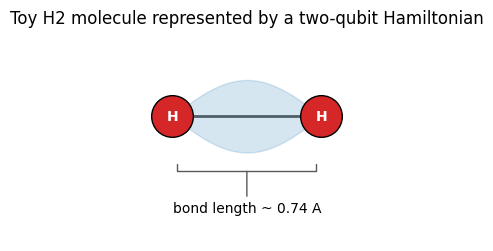

In [2]:
bond_length_angstrom = 0.74
fig, ax = plt.subplots(figsize=(6.2, 2.4), constrained_layout=True)

proton_positions = np.array([-0.5 * bond_length_angstrom, 0.5 * bond_length_angstrom])
ax.plot(proton_positions, [0, 0], color="0.35", linewidth=2.0, zorder=1)
ax.scatter(
    proton_positions, [0, 0], s=900, color="tab:red", edgecolor="black", zorder=3
)
for xpos, label in zip(proton_positions, ["H", "H"]):
    ax.text(xpos, 0, label, ha="center", va="center", color="white", weight="bold")

electron_x = np.linspace(proton_positions[0], proton_positions[1], 120)
electron_cloud = 0.18 * np.sin(np.linspace(0, np.pi, electron_x.size))
ax.fill_between(
    electron_x, -electron_cloud, electron_cloud, color="tab:blue", alpha=0.18
)
ax.annotate(
    f"bond length ~ {bond_length_angstrom:.2f} A",
    xy=(0, -0.26),
    xytext=(0, -0.48),
    ha="center",
    arrowprops={"arrowstyle": "-[,widthB=5.0,lengthB=0.5", "color": "0.35"},
)
ax.set_title("Toy H2 molecule represented by a two-qubit Hamiltonian")
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.62, 0.42)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

In [3]:
cutoff = 0.5 * (energies[0] + energies[1])
scale = np.max(np.abs(cutoff - energies))
A = (cutoff * np.eye(H.shape[0]) - H) / scale

coeffs = design_projector_polynomial(gamma=0.15, degree=17)
P_ground = apply_polynomial_to_hermitian(A, coeffs)

trial = np.array([1.0, 0.0, 0.0, 0.25])
trial = trial / np.linalg.norm(trial)
filtered = P_ground @ trial
filtered = filtered / np.linalg.norm(filtered)

ground_vec = vecs[:, 0]
initial_overlap = abs(np.vdot(ground_vec, trial)) ** 2
filtered_overlap = abs(np.vdot(ground_vec, filtered)) ** 2
energy_estimate = np.real(np.vdot(filtered, H @ filtered))

print(f"Initial Overlap [probability]: {initial_overlap}")
print(f"Filtered Overlap [probability]: {filtered_overlap}")
print(f"Energy Estimate [hartree]: {energy_estimate}")

Initial Overlap [probability]: 3.4911941432755493e-35
Filtered Overlap [probability]: 6.719832005838039e-33
Energy Estimate [hartree]: -0.9424088608987823


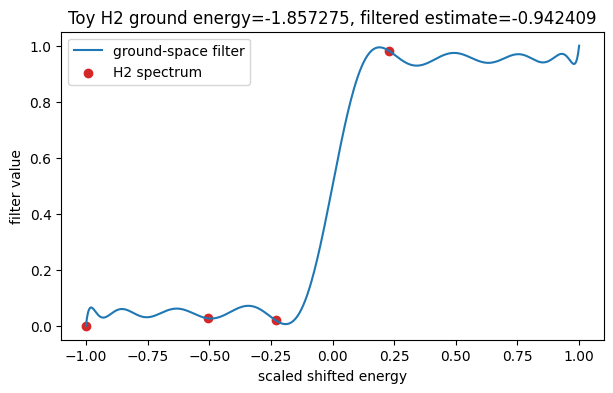

In [4]:
xs = np.linspace(-1, 1, 500)
plt.figure(figsize=(7, 4))
plt.plot(xs, eval_polynomial(coeffs, xs), label="ground-space filter")
plt.scatter(
    np.linalg.eigvalsh(A),
    eval_polynomial(coeffs, np.linalg.eigvalsh(A)),
    color="tab:red",
    label="H2 spectrum",
)
plt.xlabel("scaled shifted energy")
plt.ylabel("filter value")
plt.title(
    f"Toy H2 ground energy={ground_energy:.6f}, filtered estimate={energy_estimate:.6f}"
)
plt.legend()
plt.show()